# Decision Tree 

A **Decision Tree** is a supervised learning model that makes predictions by asking a sequence of **if–else questions** about the input features.  
You can think of it like a flowchart:

- Each **internal node** asks a question (example: *is pixel_23 ≤ 0.5?*).
- Each **branch** is the answer (Yes/No).
- Each **leaf node** gives the final prediction (a class label).

## Key Terms
- **Root node:** the first split (top of the tree).
- **Split:** a rule that divides the data into two groups.
- **Leaf:** final decision/prediction.
- **Depth:** how many levels the tree has (deeper = more complex).
- **Overfitting:** very deep trees can memorize training data and perform poorly on new data.

## How a tree decides splits (idea)
The tree tries many possible splits and chooses the one that best separates classes.
Common criteria:
- **Gini impurity** (default in sklearn)
- **Entropy** (information gain)

## Pros / Cons
**Pros**
- Easy to understand and explain
- Handles non-linear patterns
- No need to scale features (in general)

**Cons**
- Can overfit (needs depth control, pruning, min samples per leaf, etc.)
- Small changes in data can change the tree a lot

In [1]:
# ------------------------------------------------------------
# Decision Tree on sklearn Digits Dataset (Hands-on)
# Steps:
# 1) Load data
# 2) Visualize some digits with labels
# 3) Standard scaling 
# 4) Train-test split
# 5) Train Decision Tree
# 6) Evaluate (accuracy)
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
# -----------------------
# 1) Load Digits dataset
# -----------------------
digits = load_digits()


digits

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [4]:
X = digits.data          # shape: (n_samples, 64)  -> 8x8 images flattened
y = digits.target        # shape: (n_samples,)
images = digits.images   # shape: (n_samples, 8, 8)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique classes:", np.unique(y))

X shape: (1797, 64)
y shape: (1797,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


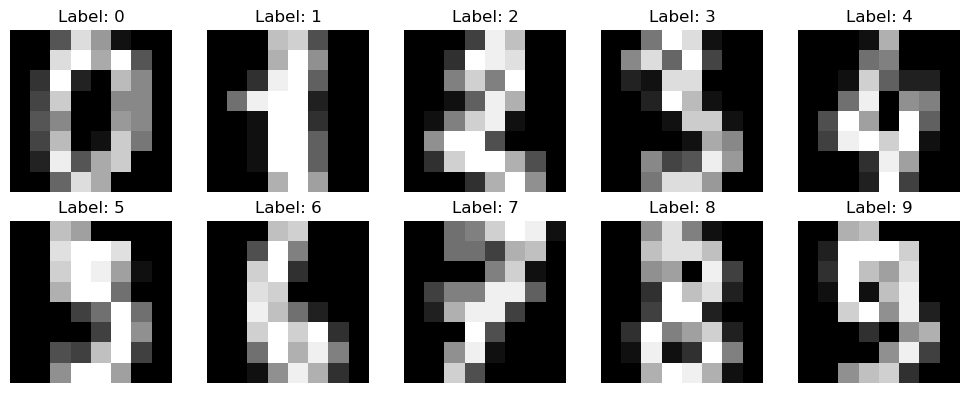

In [5]:
# -----------------------------------------
# 2) Visualize some digits with their labels
# -----------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
axes = axes.ravel()

for i in range(10):
    axes[i].imshow(images[i], cmap="gray")
    axes[i].set_title(f"Label: {y[i]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [6]:
# -----------------------------------------
# 3) Standard Scaling (requested)
# -----------------------------------------
# Scaling makes features have mean ~0 and std ~1.
# NOTE: Trees do NOT require scaling.

scaler = StandardScaler()
X = scaler.fit_transform(X)  

# -----------------------------------------
# 4) Train-test split (before scaling)
# -----------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class distribution similar in train/test
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (1437, 64) (1437,)
Test : (360, 64) (360,)


In [8]:
# -----------------------------------------
# 5) Train Decision Tree classifier
# -----------------------------------------
# max_depth controls complexity (helps reduce overfitting)
# You can change max_depth to see how performance changes.

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=10
)

dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10)

In [9]:
# -----------------------------------------
# 6) Evaluate the model
# -----------------------------------------
y_pred = dt.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)

Accuracy: 0.8416666666666667


# Random Forest

A **Random Forest** is an ensemble model made of many **Decision Trees**.

## Idea (Intuition)
Instead of training one tree on the full data, Random Forest trains **many trees** and then combines their predictions:
- For classification: **majority vote**
- For probability: **average of tree probabilities**

## Why it works better than one Decision Tree
A single decision tree can overfit. Random Forest reduces overfitting by adding randomness:
1) **Bootstrap sampling**: each tree is trained on a random sample (with replacement) of the training data  
2) **Random feature selection**: each split considers only a random subset of features  

This makes trees “less similar” → averaging them improves generalization.

## Pros / Cons
**Pros**
- Usually strong accuracy with little tuning
- Handles non-linear patterns well
- Less overfitting than a single tree

**Cons**
- Slower and heavier than a single tree
- Harder to interpret than one tree

In [5]:
# ------------------------------------------------------------
# Random Forest on Wine dataset (sklearn)
# Steps:
# 1) Load dataset
# 2) Visualize data with labels
# 3) Standard scaling 
# 4) Train-test split
# 5) Train Random Forest
# 6) Evaluate
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
# -----------------------
# 1) Load Wine dataset
# -----------------------
wine = load_wine()
X = wine.data
y = wine.target
feature_names = wine.feature_names
class_names = wine.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", class_names)
print("First 3 feature names:", feature_names[:3])

X shape: (178, 13)
y shape: (178,)
Classes: ['class_0' 'class_1' 'class_2']
First 3 feature names: ['alcohol', 'malic_acid', 'ash']


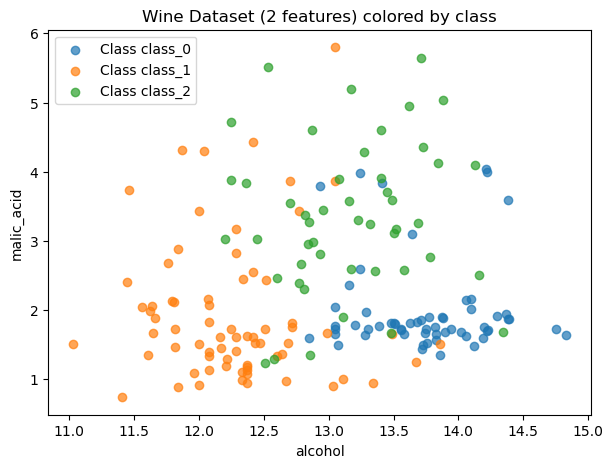

In [7]:
# ------------------------------------------------------------
# 2) Visualization: 2D scatter using two features
# ------------------------------------------------------------
# We'll use feature 0 vs feature 1 to visualize class separation

plt.figure(figsize=(7, 5))
for c in np.unique(y):
    plt.scatter(
        X[y == c, 0], X[y == c, 1],
        label=f"Class {class_names[c]}",
        alpha=0.7
    )
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Wine Dataset (2 features) colored by class")
plt.legend()
plt.show()

In [8]:
# -----------------------
# 3) Standard scaling
# -----------------------


scaler = StandardScaler()
X = scaler.fit_transform(X)

# -----------------------
# 4) Train-test split
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (142, 13) (142,)
Test : (36, 13) (36,)


In [10]:
# 4) Train model
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

RandomForestClassifier()

In [11]:
y_pred = rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [12]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

y_pred[:2]

array([0, 2])

# K-Nearest Neighbors (KNN)



**KNN** is a supervised learning algorithm that classifies a new point by looking at the **K closest training points**.

## How it works
1) Choose a value of **K** (e.g., 3, 5, 7).
2) For a new sample, compute its distance to all training samples (usually Euclidean distance).
3) Pick the **K nearest neighbors**.
4) Predict the class by **majority vote** among those neighbors.

## Important note (very important)
KNN is **distance-based**, so **feature scaling is necessary** (standardization or min–max).
Without scaling, features with large ranges dominate the distance.

## Pros / Cons
**Pros:** simple, no training time (lazy learner)  
**Cons:** slow prediction on large data, sensitive to scaling and K choice

In [1]:
# ------------------------------------------------------------
# KNN on Iris dataset (sklearn)
# Steps:
# 1) Load data
# 2) Visualize with labels (2 features)
# 3) Train-test split
# 4) Scale AFTER split using Pipeline
# 5) Train KNN
# 6) Evaluate
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X shape: (150, 4)
y shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


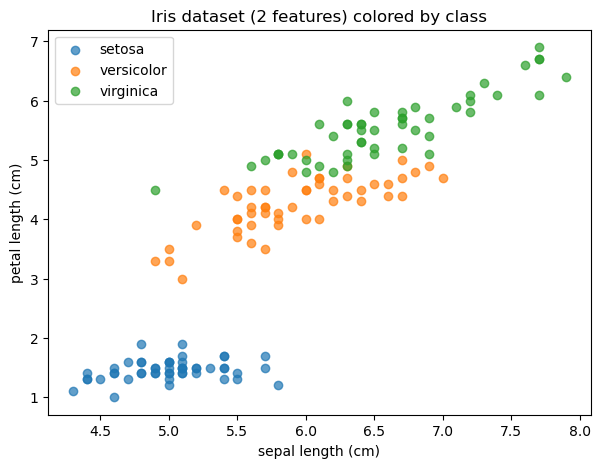

In [3]:
# 1) Load Iris
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", class_names)

# 2) Visualize using two features (simple 2D scatter)
# We'll use feature 0 vs feature 2 (sepal length vs petal length) for clearer separation

f1, f2 = 0, 2

plt.figure(figsize=(7, 5))
for c in np.unique(y):
    plt.scatter(
        X[y == c, f1],
        X[y == c, f2],
        label=class_names[c],
        alpha=0.7
    )

plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.title("Iris dataset (2 features) colored by class")
plt.legend()
plt.show()

In [4]:
# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
# 4) Scaling AFTER split (no leakage) + 5) Train KNN using Pipeline
# Pipeline ensures scaler is fit ONLY on training data.
# K=5 is a common starting point.

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

In [6]:
# 6) Evaluate
y_pred = knn_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9333333333333333


In [7]:
# Optional: try different K values quickly
for k in [1, 3, 5, 7, 9]:
    pipe = Pipeline([("scaler", StandardScaler()),
                     ("knn", KNeighborsClassifier(n_neighbors=k))])
    pipe.fit(X_train, y_train)
    acc = pipe.score(X_test, y_test)
    print(f"K={k} -> Accuracy={acc:.3f}")

K=1 -> Accuracy=0.967
K=3 -> Accuracy=0.933
K=5 -> Accuracy=0.933
K=7 -> Accuracy=0.967
K=9 -> Accuracy=0.967


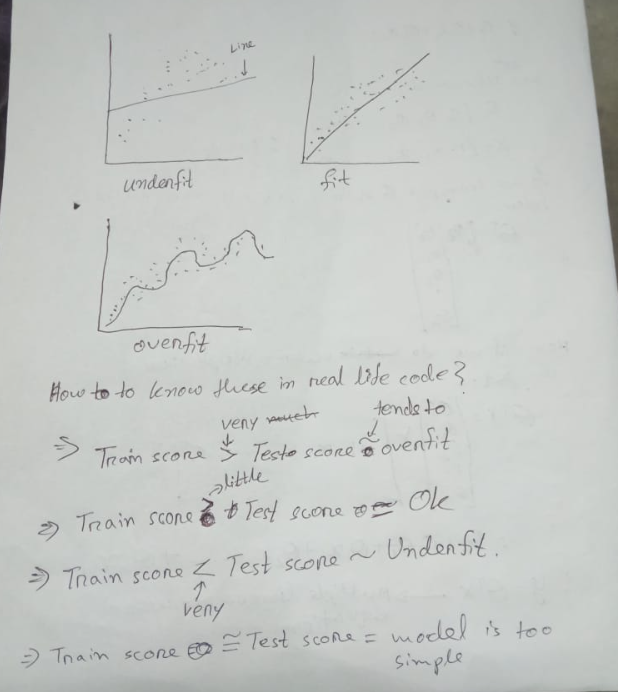

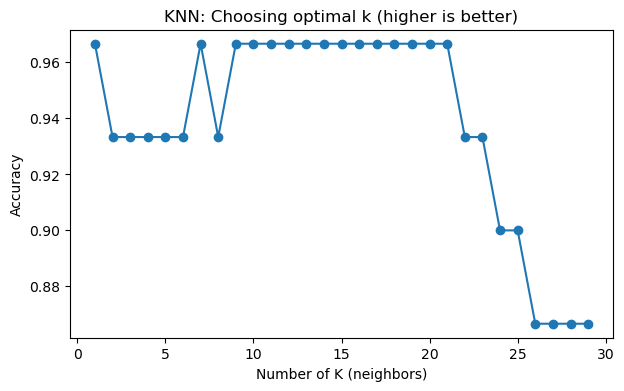

Best k = 1 with accuracy = 0.9666666666666667


In [8]:
# Try different k values and store accuracy
k_range = range(1, 30)
acc_scores = []

for k in k_range:
    knn_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    knn_pipeline.fit(X_train, y_train)
    acc_scores.append(knn_pipeline.score(X_test, y_test))  # accuracy on test set

# Plot k vs accuracy (elbow-style)
plt.figure(figsize=(7, 4))
plt.xlabel("Number of K (neighbors)")
plt.ylabel("Accuracy")
plt.plot(k_range, acc_scores, marker="o")
plt.title("KNN: Choosing optimal k (higher is better)")
plt.show()

# Best k
best_k = k_range[int(np.argmax(acc_scores))]
best_acc = max(acc_scores)
print("Best k =", best_k, "with accuracy =", best_acc)

# Support Vector Machine (SVM) 



**SVM** is a supervised learning algorithm for classification that tries to find the **best separating boundary** between classes.

## Key idea (in 2D intuition)
Imagine drawing a line that separates two classes.  
SVM chooses the line (or hyperplane) that **maximizes the margin** — the distance between the boundary and the closest points from each class.

- The closest points are called **support vectors**.
- Larger margin usually means better generalization.

## Kernels (how SVM handles non-linear data)
- **Linear kernel:** straight boundary
- **RBF kernel:** curved boundary (default and powerful)
- **Polynomial kernel:** polynomial-shaped boundary

## Important note
SVM is **distance/scale sensitive**, so **scaling is important** (StandardScaler is common).

In [9]:
# ------------------------------------------------------------
# SVM on Iris dataset (sklearn)
# Steps:
# 1) Load data
# 2) Visualize with labels (2 features)
# 3) Train-test split
# 4) Scale AFTER split using Pipeline (no leakage)
# 5) Train SVM
# 6) Evaluate
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
# 1) Load Iris
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
class_names = iris.target_names

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", class_names)

X shape: (150, 4)
y shape: (150,)
Classes: ['setosa' 'versicolor' 'virginica']


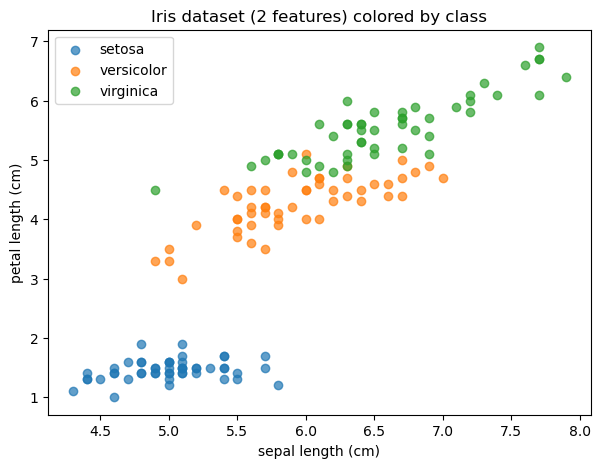

In [11]:
# 2) Visualize using two features
# We'll use feature 0 vs feature 2 (often shows separation)

f1, f2 = 0, 2

plt.figure(figsize=(7, 5))
for c in np.unique(y):
    plt.scatter(
        X[y == c, f1],
        X[y == c, f2],
        label=class_names[c],
        alpha=0.7
    )

plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.title("Iris dataset (2 features) colored by class")
plt.legend()
plt.show()

In [13]:
# 3) Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [14]:
# 4) Scale AFTER split + 5) Train SVM using Pipeline
# We'll use RBF kernel (default is good). C controls regularization.

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=42))
])

svm_pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm', SVC(probability=True, random_state=42))])

In [15]:
# 6) Evaluate
y_pred = svm_pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


# Naive Bayes for Text Classification



**Naive Bayes (NB)** is a probabilistic classifier based on **Bayes’ Theorem**.

## Bayes’ Theorem (idea)
It computes the probability of a class given the text:

$$
P(c \mid x) = \frac{P(x \mid c)\,P(c)}{P(x)}
$$

- $c$ = class (e.g., `rec.autos`, `sci.space`)
- $x$ = the text/document
- $P(c)$ = prior probability of the class
- $P(x \mid c)$ = likelihood of seeing the words in the class
- We pick the class with the highest probability.

## Why “Naive”?
NB assumes words are conditionally independent given the class:
- If a document contains words $w_1, w_2, ..., w_n$, NB assumes:

$$
P(x \mid c) \approx \prod_{i=1}^{n} P(w_i \mid c)
$$

This assumption is not perfectly true in language, but it works surprisingly well.

## Why it’s great for text
Text data is **high-dimensional** (many words). NB is:
- fast
- simple
- strong baseline for text classification

## Common NB for text
- **MultinomialNB**: works well with word counts / TF-IDF features

In [16]:
import re
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
categories = ["rec.autos", "sci.space", "sci.med"]

train_data = fetch_20newsgroups(
    subset="train",
    categories=categories,
    remove=("headers", "footers", "quotes")  # removes obvious metadata
)

test_data = fetch_20newsgroups(
    subset="test",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

X_train_raw, y_train = train_data.data, train_data.target
X_test_raw, y_test = test_data.data, test_data.target
target_names = train_data.target_names

print("Train size:", len(X_train_raw))
print("Test size :", len(X_test_raw))
print("Classes   :", target_names)

Train size: 1781
Test size : 1186
Classes   : ['rec.autos', 'sci.med', 'sci.space']


In [18]:
def clean_text(text: str) -> str:
    # 1) lowercase
    text = text.lower()
    
    # 2) remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)
    
    # 3) keep only letters (replace everything else with space)
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # 4) tokenize
    tokens = text.split()
    
    # 5) remove stopwords + short tokens
    tokens = [t for t in tokens if t not in ENGLISH_STOP_WORDS and len(t) > 2]
    
    # return cleaned text (space-separated tokens)
    return " ".join(tokens)

# quick demo: see before/after on one sample
sample = X_train_raw[0]
print("BEFORE:\n", sample[:400], "\n")
print("AFTER:\n", clean_text(sample)[:400])

BEFORE:
 
A(>  Can anyone tell me if a bloodcount of 40 when diagnosed as hypoglycemic is
A(>  dangerous, i.e. indicates a possible pancreatic problem?  One Dr. says no, the
A(>  other (not his specialty) says the first is negligent and that another blood
A(>  test should be done.  Also, what is a good diet (what has worked) for a hypo-
A(>  glycemic?  TIA.
A(>  
A(>  
A(>  Anthony Anello
A(>  Fermilab
A(> 

AFTER:
 tell bloodcount diagnosed hypoglycemic dangerous indicates possible pancreatic problem says specialty says negligent blood test good diet worked hypo glycemic tia anthony anello fermilab batavia illinois hypoglycemia confirmed proper channels consider ther following chelated manganese day chelated chromium mcg day increase protein foods supplements avoid supplements foods high potassium calcium zi


In [19]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

# Pipeline = run multiple steps in order (text -> numbers -> classifier)
model = Pipeline([
    # Step 1: TF-IDF Vectorizer (converts text into numeric feature vectors)
    #
    # What TF-IDF does:
    # - It builds a "vocabulary" of words from the training text.
    # - For each document, it creates a long vector where each position corresponds to a word.
    # - The value at each position is the TF-IDF score of that word in that document.
    #
    # TF (Term Frequency): how often a word appears in a document.
    # IDF (Inverse Document Frequency): reduces the weight of common words
    #   (words that appear in many documents get lower weight).
    #
    # Result: each document becomes a numeric vector that represents "important words".
    #
    # preprocessor=clean_text means: before vectorizing, apply our cleaning function
    # (lowercase, remove punctuation, remove stopwords, etc.)
    #
    # min_df=2 means: ignore words that appear in fewer than 2 documents
    # (removes very rare words/noise).
    ("tfidf", TfidfVectorizer(preprocessor=clean_text, min_df=2)),

    # Step 2: Multinomial Naive Bayes classifier
    #
    # This model learns:
    # - which words are common in each class (cars vs space vs medical)
    # - then predicts the class of a new document using those learned word probabilities.
    ("nb", MultinomialNB())
])

# Train the pipeline:
# - tfidf step learns vocabulary + transforms training text into TF-IDF vectors
# - nb step learns class probabilities from those vectors
model.fit(X_train_raw, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2,
                                 preprocessor=<function clean_text at 0x176c7a520>)),
                ('nb', MultinomialNB())])

In [20]:
y_pred = model.predict(X_test_raw)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8988195615514334


In [21]:
for i in [0, 5, 20]:
    text = X_test_raw[i]
    pred = model.predict([text])[0]
    
    # show top 2 predicted probabilities (optional)
    probs = model.predict_proba([text])[0]
    top2 = probs.argsort()[-2:][::-1]
    
    print("="*70)
    print("TRUE:", target_names[y_test[i]])
    print("PRED:", target_names[pred])
    print("Top-2 probs:", [(target_names[j], float(probs[j])) for j in top2])
    print("\nTEXT SNIPPET:\n", text[:400])

TRUE: rec.autos
PRED: rec.autos
Top-2 probs: [('rec.autos', 0.7576749879869539), ('sci.med', 0.14134906476211964)]

TEXT SNIPPET:
 I still can't understand all the hype about the Impalla SS, it STILL has
the ugly Caprice body (Orca on wheels).  The Caprice was the worst new
body style to come out of Detroit EVER! Now just because the LT1 engine
and a few suspension tweeks are being added.

Its STILL UGLY, its STILL a BARGE.  GM's answer to everything is "throw in
a V8 and someone will buy it."  Or "add some plastic ground aff
TRUE: sci.space
PRED: rec.autos
Top-2 probs: [('rec.autos', 0.37226896665297776), ('sci.space', 0.33113415911495264)]

TEXT SNIPPET:
 

This is a whole different situation.  If aliens were able to get here prior
to us being able to get there, one might conclude that they would be more advanced
and therefore "more intelegent" that we are.  However if we get somewhere where there
is life, chances are we wont be able to communicate with them.  So we will have
no clue

# Ensemble Learning: Bagging vs Boosting


## Bagging (Bootstrap Aggregating)
**Idea:** Train many models **independently** and combine their predictions.

- Each model sees a **random bootstrap sample** (sample with replacement).
- For classification: **majority vote**
- For regression: **average**

**Why it helps:** reduces **variance** (makes the model more stable, less overfitting).  
**Example:** Random Forest (bagging + random feature selection).

---

## Boosting
**Idea:** Train models **sequentially**, where each new model focuses on fixing the mistakes of the previous ones.

- Model 1 learns a rough boundary.
- Model 2 focuses more on samples that were misclassified.
- Model 3 fixes what model 2 still misses, etc.

**Why it helps:** reduces **bias** (builds a stronger model from many weak ones).  
**Example:** AdaBoost, Gradient Boosting.

---

Bias is the error from making a model too simple, so it misses the real pattern in the data (underfitting). If a model has high bias, it performs poorly even on the training data because it cannot learn the relationship well.

Variance is the error from making a model too sensitive to the training data, so it learns noise and changes a lot if the training set changes (overfitting). If a model has high variance, it can perform very well on training data but worse on new/test data.

In short: high bias → underfit, high variance → overfit, and good models aim to balance both.

## One-line memory trick
- **Bagging:** parallel, reduces variance   
- **Boosting:** sequential, reduces bias 

# AdaBoost (Stumps)

**AdaBoost** = Adaptive Boosting.  
It combines many **weak learners** (usually **decision stumps**, i.e., trees with `max_depth=1`) into a strong classifier.

## Core idea
1) Start with equal weight on all training samples.  
2) Train a weak classifier (stump).  
3) Increase weight for the samples it got wrong (so the next stump "pays attention" to them).  
4) Repeat many rounds.  
5) Final prediction = **weighted vote** of all weak learners.

So each new stump focuses on the "hard" points.

In [22]:
# ------------------------------------------------------------
# AdaBoost (stumps) on Iris dataset
# Steps:
# 1) Load Iris
# 2) Train-test split
# 3) Train AdaBoost with decision stumps
# 4) Evaluate
# ------------------------------------------------------------

import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [23]:
# 1) Load data
iris = load_iris()
X, y = iris.data, iris.target
class_names = iris.target_names

# 2) Split (no scaling required for trees/stumps)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# 3) Weak learner = decision stump (tree depth 1)
stump = DecisionTreeClassifier(max_depth=1, random_state=42)

# AdaBoost builds many stumps sequentially
ada = AdaBoostClassifier(
    estimator=stump,      # weak learner
    n_estimators=100,     # number of stumps
    learning_rate=0.8,    # how much each stump contributes
    random_state=42
)

ada.fit(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   learning_rate=0.8, n_estimators=100, random_state=42)

In [25]:
# 4) Evaluate
y_pred = ada.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8666666666666667


In [26]:
# Optional: Compare with a single stump to show why boosting helps
single_stump = DecisionTreeClassifier(max_depth=1, random_state=42)
single_stump.fit(X_train, y_train)
stump_pred = single_stump.predict(X_test)

print("Single stump accuracy:", accuracy_score(y_test, stump_pred))
print("AdaBoost accuracy     :", accuracy_score(y_test, y_pred))

Single stump accuracy: 0.6666666666666666
AdaBoost accuracy     : 0.8666666666666667
